## Impl directories to analyze

In [11]:
from pathlib import Path

MODES = ["noDesign", "allAtOnce"] # , "allAtOnce", "byLayer"]
PROBLEM = "mocked_http"

dirs = [
    Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/implementations_{x}") for x in MODES
]
dirs

[PosixPath('datasets/slopCodeBench/scb-problems/mocked_http/implementations_noDesign'),
 PosixPath('datasets/slopCodeBench/scb-problems/mocked_http/implementations_allAtOnce')]

## Obtain overall metrics

In [12]:
import os 
from deterministic.overall_metrics.get_overall_metrics import get_overall_metrics


# An array of arrays, each of length N 
# where N is the number of checkpoints of the problem 
data = [] 

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # walk through each checkpoint 
    mode_metrics = []  # metrics of all checkpoints, for a single mode 
    for i, checkpoint_name in enumerate(checkpoint_dirs): 
        impl_dir = dirs[mode_no] / checkpoint_name
        
        mode_metrics.append(
            get_overall_metrics(impl_dir) 
        )
    
    data.append(mode_metrics) 

print(data)

[1/2] DPy metrics
invoking license validation...
DPy version 1.7.8 Trial
Copyright (c) Designite 2026.
Current Configuration:
  Input Path: /home/bernardmoy/modular-SWE/datasets/slopCodeBench/scb-problems/mocked_http/implementations_noDesign/checkpoint_1
  Output Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
  Output Format: json
  Configuration File: /tmp/onefile_151182_1783629324_129610/default_config.json
  Log Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
invoking license validation...
License type: LicenseType.Trial
Parsing ...
Calculating metrics ...
Detecting code smells ...
Detecting design smells ...
Detecting architecture smells ...
Detecting machine learning smells ...
Collect dependencies ...
Analysis complete.
Preparing analysis summary ...
--Analysis summary--
	Total LOC analyzed: 645	Number of packages: 1
	Number of classes: 8	Number of modules: 5
	number of methods/functions: 57
-Total architecture smell instances detected-
	God com

## Logical lines of code 
Not code quality, but instead indicate the complexity of the problem checkpoint.

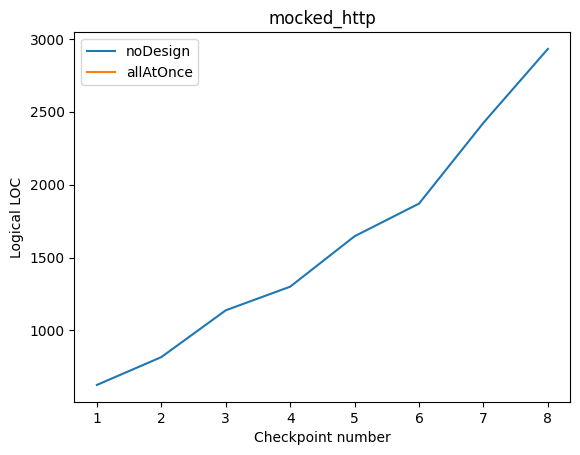

In [13]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z["lloc"] for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Logical LOC")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Maintainability index

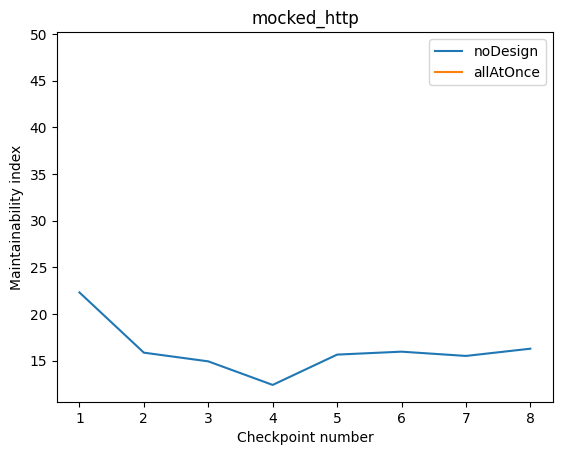

In [14]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z["weighted_maintainability_index"] for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Maintainability index")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Functions with high CC

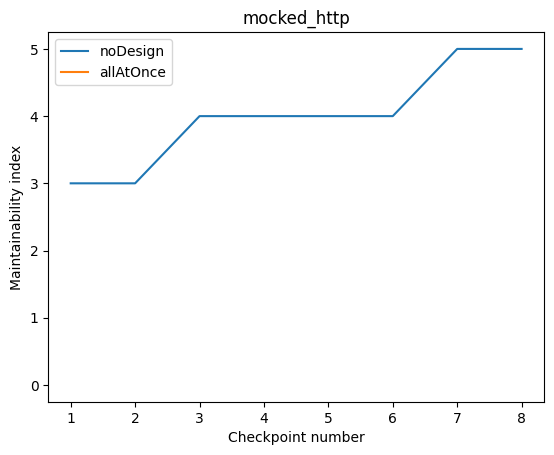

In [15]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z["function_cyclomatic_complexity_count"] for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Maintainability index")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Duplicated lines percentage

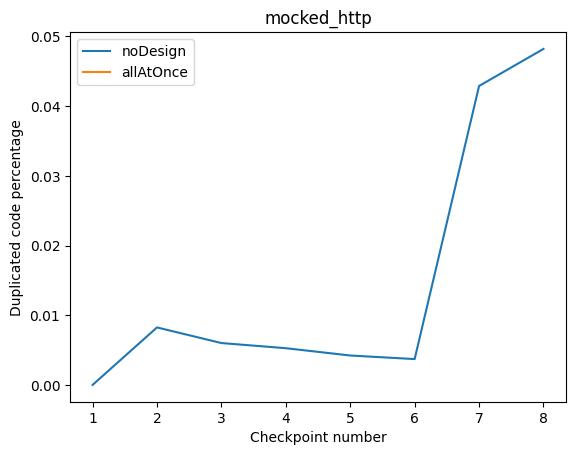

In [16]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z["duplicated_code_percent"] for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Duplicated code percentage")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Maintenance effort

Files change together and the changed proportion

In [7]:
from deterministic.overall_metrics.maintenance_effort import get_changed_files
from collections import defaultdict


for mode_no, mode in enumerate(MODES): 
    pairs = defaultdict(int) 

    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # walk through each checkpoint pairs 
    mode_metrics = []  # metrics of all checkpoints, for a single mode 
    for i in range(len(checkpoint_dirs)-1): 
        old_checkpoint = checkpoint_dirs[i] 
        new_checkpoint = checkpoint_dirs[i+1]
        changed_files = get_changed_files(
            dirs[mode_no] / old_checkpoint, 
            dirs[mode_no] / new_checkpoint
        )
        
        # Walk through each pairs 
        for i in range(len(changed_files)): 
            for j in range(i+1, len(changed_files)): 
                pairs[(changed_files[i], changed_files[j])] += 1 
        
    view = [(key, value) for key, value in pairs.items()]
    view.sort(key=lambda x: x[1], reverse=True)
    print('\n'.join([str(x) for x in view]))
    print("="*50)

(('circ_errors.py', 'circopt.py'), 6)
(('circ_parser.py', 'circ_errors.py'), 3)
(('circ_parser.py', 'circopt.py'), 3)
(('circ_errors.py', 'circ_eval.py'), 3)
(('circopt.py', 'circ_eval.py'), 3)
(('circ_validator.py', 'circ_parser.py'), 2)
(('circ_validator.py', 'circ_model.py'), 2)
(('circ_validator.py', 'circ_errors.py'), 2)
(('circ_validator.py', 'circopt.py'), 2)
(('circ_validator.py', 'circ_eval.py'), 2)
(('circ_parser.py', 'circ_model.py'), 2)
(('circ_parser.py', 'circ_eval.py'), 2)
(('circ_model.py', 'circ_errors.py'), 2)
(('circ_model.py', 'circopt.py'), 2)
(('circ_model.py', 'circ_eval.py'), 2)
(('circ_errors.py', 'circ_commands.py'), 1)
(('circopt.py', 'circ_commands.py'), 1)
(('circopt_cli.py', 'circopt_errors.py'), 3)
(('circopt_eval_inputs.py', 'circopt_commands_eval.py'), 2)
(('circopt_eval_inputs.py', 'circopt_evaluator.py'), 2)
(('circopt_eval_inputs.py', 'circopt_cli.py'), 2)
(('circopt_eval_inputs.py', 'circopt_errors.py'), 2)
(('circopt_commands_eval.py', 'circopt_eva

## 

## Proportion of code that is changed

In [8]:
from deterministic.overall_metrics.maintenance_effort import get_changed_proportion
import os 

data = [] 
for mode_no, mode in enumerate(MODES): 

    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # walk through each checkpoint pairs 
    mode_metrics = []  # metrics of all checkpoints, for a single mode 
    for i in range(len(checkpoint_dirs)-1): 
        old_checkpoint = checkpoint_dirs[i] 
        new_checkpoint = checkpoint_dirs[i+1]
        p = get_changed_proportion(
            dirs[mode_no] / old_checkpoint, 
            dirs[mode_no] / new_checkpoint
        )
        mode_metrics.append(p) 
    data.append(mode_metrics)
print(data)

[[0.4, 1.0, 0.5, 1.0, 0.16666666666666666, 0.42857142857142855, 0.375], [0.25, 0.8181818181818182, 0.5]]


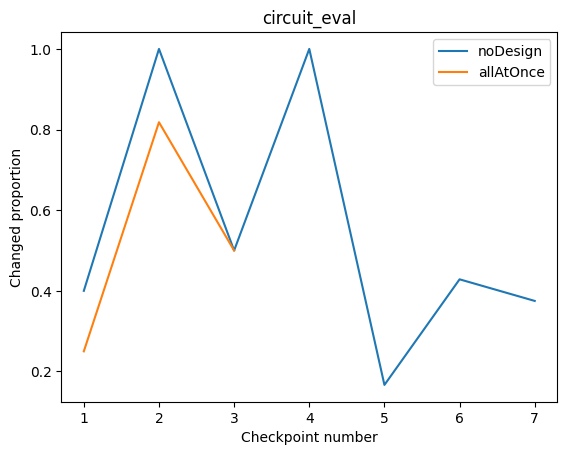

In [9]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Changed proportion")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Deps graph

In [10]:
from deterministic.overall_metrics.deps_graph import get_deps_graph_metrics
import os 

data = [] 
for mode_no, mode in enumerate(MODES): 

    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # walk through each checkpoint pairs 
    mode_metrics = []  # metrics of all checkpoints, for a single mode 
    for i, checkpoint_name in enumerate(checkpoint_dirs): 
        impl_dir = dirs[mode_no] / checkpoint_name
        
        mode_metrics.append(
            get_deps_graph_metrics(impl_dir) 
        )
    
    data.append(mode_metrics) 
print(data)

[GRAPH 1/2] Generating dependency graph...
[GRAPH 2/2] Converting the dependency graphs to JSON...
Dependency graph has 5 modules.
[GRAPH 1/2] Generating dependency graph...
[GRAPH 2/2] Converting the dependency graphs to JSON...
Dependency graph has 6 modules.
[GRAPH 1/2] Generating dependency graph...
[GRAPH 2/2] Converting the dependency graphs to JSON...
Dependency graph has 6 modules.
[GRAPH 1/2] Generating dependency graph...
[GRAPH 2/2] Converting the dependency graphs to JSON...
Dependency graph has 6 modules.
[GRAPH 1/2] Generating dependency graph...
[GRAPH 2/2] Converting the dependency graphs to JSON...
Dependency graph has 6 modules.
[GRAPH 1/2] Generating dependency graph...
[GRAPH 2/2] Converting the dependency graphs to JSON...
Dependency graph has 7 modules.
[GRAPH 1/2] Generating dependency graph...
[GRAPH 2/2] Converting the dependency graphs to JSON...
Dependency graph has 8 modules.
[GRAPH 1/2] Generating dependency graph...
[GRAPH 2/2] Converting the dependency gr

Traceback (most recent call last):
  File "/home/bernardmoy/modular-SWE/scripts/process_deps_graph.py", line 68, in <module>
    main()
  File "/home/bernardmoy/modular-SWE/scripts/process_deps_graph.py", line 42, in main
    G = nx.nx_pydot.read_dot(args.path) 
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/bernardmoy/modular-SWE/.venv/lib/python3.12/site-packages/networkx/utils/decorators.py", line 784, in func
    return argmap._lazy_compile(__wrapper)(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<class 'networkx.utils.decorators.argmap'> compilation 6", line 5, in argmap_read_dot_1
  File "/home/bernardmoy/modular-SWE/.venv/lib/python3.12/site-packages/networkx/utils/backends.py", line 551, in _call_if_no_backends_installed
    return self.orig_func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/bernardmoy/modular-SWE/.venv/lib/python3.12/site-packages/networkx/drawing/nx_pydot.py", line 85, in read_dot
    P

KeyboardInterrupt: 

## Has cycles

In [ ]:
for i, entry in enumerate(data): 
    print(f"{MODES[i]}: {[x["hasCycles"] for x in entry]}")

noDesign: [False, False, False, False, False, False, False, False]
allAtOnce: [False, False, False, False]


## Propagation cost

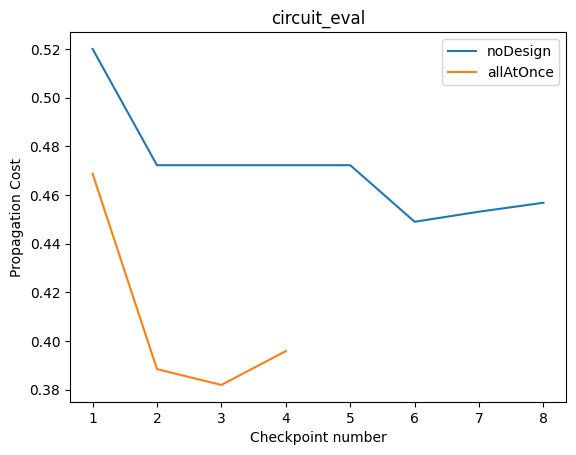

In [ ]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z["propagationCost"] for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Propagation Cost")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

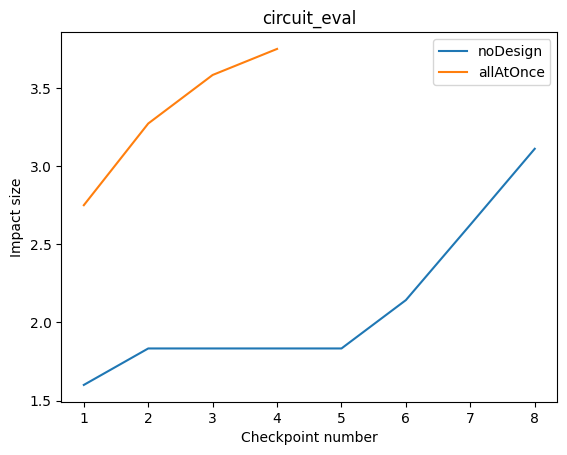

In [ ]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z["impactSize"] for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Impact size")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

In [ ]:
import os 
from deterministic.overall_metrics.maintenance_effort import get_changed_files_from_history

# An array of arrays, each of length N 
# where N is the number of checkpoints of the problem 
data = [] 

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # walk through each checkpoint 
    checkpoint_dirs_abs = [dirs[mode_no] / checkpoint_name for checkpoint_name in checkpoint_dirs]
    d = get_changed_files_from_history(checkpoint_dirs_abs)
    print(d)

print(data)

defaultdict(<class 'int'>, {'circ_errors.py': 6, 'circopt.py': 7, 'circ_validator.py': 2, 'circ_parser.py': 3, 'circ_model.py': 2, 'circ_eval.py': 3, 'circ_commands.py': 1})
defaultdict(<class 'int'>, {'circopt_cli.py': 3, 'circopt_errors.py': 3, 'circopt_eval_inputs.py': 2, 'circopt_model.py': 1, 'circopt_commands_eval.py': 2, 'circopt_evaluator.py': 2, 'circopt_parser.py': 1, 'circopt_commands_check.py': 1, 'circopt_validator.py': 1, 'circopt_values.py': 1})
[]


In [ ]:
# from deterministic.overall_metrics.deps_graph import get_weighted_deps_graph_metrics
# import os 
# from deterministic.overall_metrics.maintenance_effort import get_changed_files_from_history

# data = [] 
# for mode_no, mode in enumerate(MODES): 

#     # Obtain the checkpoint directories names of the problem
#     # checkpoint_1, checkpoint_2, ... checkpoint_N
#     checkpoint_dirs = []
#     for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
#         # only extract the top level iteration 
#         checkpoint_dirs = dir 
#         break 
#     checkpoint_dirs.sort() 

#     checkpoint_dirs_abs = [dirs[mode_no] / checkpoint_name for checkpoint_name in checkpoint_dirs]
#     d = get_changed_files_from_history(checkpoint_dirs_abs)

#     # walk through each checkpoint pairs 
#     mode_metrics = []  # metrics of all checkpoints, for a single mode 
#     for i, checkpoint_name in enumerate(checkpoint_dirs): 
#         impl_dir = dirs[mode_no] / checkpoint_name
        
#         mode_metrics.append(
#             get_weighted_deps_graph_metrics(d, impl_dir)
#         )
    
#     data.append(mode_metrics) 
# print(data)

In [ ]:
# from matplotlib import pyplot as plt 

# for i, entry in enumerate(data): 
#     x = range(1, len(entry)+1)  # make the x axis 1 indexed 
#     y = [z["density"] for z in entry]
#     plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
# plt.xlabel("Checkpoint number")
# plt.ylabel("Density")
# plt.title(PROBLEM) 

# plt.legend() 
# plt.show() 